# 第二章配套代码：量化策略构建

本 notebook 对应 `02_strategies.md`，依次生成讲义中引用的所有图表，并提供各策略的完整实现。

**运行前请确认**：
- 已安装：`baostock`, `pandas`, `numpy`, `scipy`, `statsmodels`, `matplotlib`, `vectorbt`
- 已在项目根目录下执行
- `data/stock/` 目录下已有第一章下载的 CSV 数据（若无，运行第0节重新下载）

安装 vectorbt：`pip install vectorbt`

## 第0节　环境设置

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

warnings.filterwarnings('ignore')

import matplotlib, platform
if platform.system() == 'Windows':
    matplotlib.rc('font', family='Microsoft YaHei')
elif platform.system() == 'Darwin':
    matplotlib.rc('font', family='PingFang SC')
else:
    matplotlib.rc('font', family='WenQuanYi Micro Hei')
matplotlib.rcParams['axes.unicode_minus'] = False
matplotlib.rcParams['figure.dpi'] = 150
matplotlib.rcParams['savefig.dpi'] = 150
matplotlib.rcParams['savefig.bbox'] = 'tight'

os.makedirs('data/stock', exist_ok=True)
os.makedirs('figs', exist_ok=True)

# ------------------------------------------------------------------
# 全局常量
# ------------------------------------------------------------------
TRADING_DAYS = 252
RF_ANNUAL    = 0.02
RF_DAILY     = RF_ANNUAL / TRADING_DAYS
FEES         = 0.002   # 双边手续费 0.2%
SLIPPAGE     = 0.001   # 滑点 0.1%

STOCK_CODES = {'600036': '招商银行', '601633': '长城汽车', '000063': '中兴通讯'}
COLORS      = {'招商银行': '#1f77b4', '长城汽车': '#d62728', '中兴通讯': '#2ca02c'}

print('环境设置完毕')

环境设置完毕


In [2]:
# ------------------------------------------------------------------
# 读取所有股票数据，计算日对数收益率，对齐到同一时间轴
# ------------------------------------------------------------------
price_dict = {}
ret_dict   = {}

for code, name in STOCK_CODES.items():
    path = f'data/stock/stock_{code}.csv'
    if not os.path.exists(path):
        print(f'缺少数据文件：{path}，请先运行第一章 notebook 下载数据')
        continue
    df = pd.read_csv(path, parse_dates=['日期']).set_index('日期').sort_index()
    df = df[df['收盘价'] > 0]
    price_dict[name] = df['收盘价']
    ret_dict[name]   = np.log(df['收盘价'] / df['收盘价'].shift(1))

price_df = pd.DataFrame(price_dict).dropna()
ret_df   = pd.DataFrame(ret_dict).dropna()
print(f'数据加载完毕：{len(price_df)} 个交易日，{price_df.index[0].date()} — {price_df.index[-1].date()}')

数据加载完毕：1515 个交易日，2020-01-02 — 2026-04-07


## 第1节　四模块框架示意图

生成图：`fig_strategies_01_framework.png`

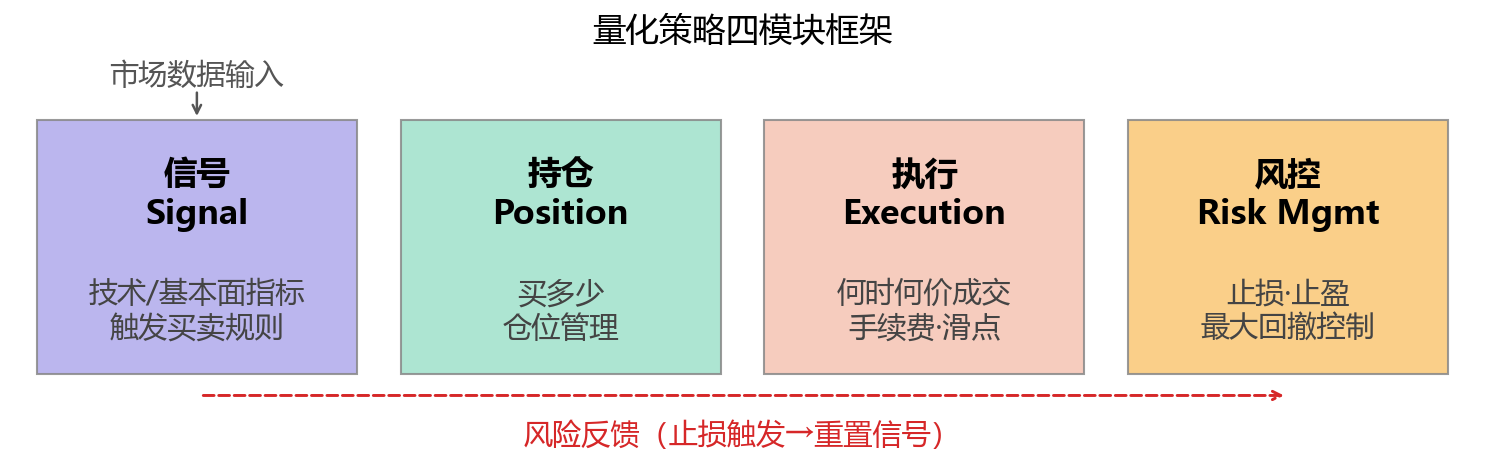

图片已保存：./figs/fig_strategies_01_framework.png


In [24]:
# ------------------------------------------------------------------
# 用 matplotlib 绘制四模块流程示意图（纯示意，不依赖真实数据）
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.set_xlim(0, 10)
ax.set_ylim(0, 4)
ax.axis('off')

modules = [
    ('信号\nSignal',    '技术/基本面指标\n触发买卖规则',    1.25, '#AFA9EC'),
    ('持仓\nPosition',  '买多少\n仓位管理',              3.75, '#9FE1CB'),
    ('执行\nExecution', '何时何价成交\n手续费·滑点',       6.25, '#F5C4B3'),
    ('风控\nRisk Mgmt', '止损·止盈\n最大回撤控制',         8.75, '#FAC775'),
]

for title, subtitle, cx, color in modules:
    # 绘制矩形
    rect = plt.Rectangle((cx - 1.1, 0.8), 2.2, 2.4, linewidth=1,
                          edgecolor='#888', facecolor=color, alpha=0.85,
                          zorder=2)
    ax.add_patch(rect)
    # 标题
    ax.text(cx, 2.5, title, ha='center', va='center',
            fontsize=16, fontweight='bold', zorder=3)
    # 副标题
    ax.text(cx, 1.4, subtitle, ha='center', va='center',
            fontsize=14, color='#444', zorder=3)

# 绘制箭头（模块间连接）
for x in [2.35, 4.85, 7.35]:
    ax.annotate('', xy=(x + 0.0, 2.0), xytext=(x - 0.0, 2.0),
                arrowprops=dict(arrowstyle='->', color='#555', lw=1.5))

# 数据输入标注
ax.text(1.25, 3.55, '市场数据输入', ha='center', fontsize=14, color='#555',
        style='italic')
ax.annotate('', xy=(1.25, 3.2), xytext=(1.25, 3.5),
            arrowprops=dict(arrowstyle='->', color='#555', lw=1.2))

# 风险反馈箭头（风控 → 信号的反馈）
ax.annotate('', xy=(1.25, 0.6), xytext=(8.75, 0.6),
            arrowprops=dict(arrowstyle='<-', color='#d62728',
                            lw=1.4, linestyle='dashed',
                            connectionstyle='arc3,rad=0'))
ax.text(5.0, 0.15, '风险反馈（止损触发→重置信号）',
        ha='center', fontsize=14, color='#d62728', style='italic')

fig.suptitle('量化策略四模块框架', fontsize=16, y=0.89)
plt.tight_layout()
plt.savefig('./figs/fig_strategies_01_framework.png', bbox_inches='tight')
plt.show()
print('图片已保存：./figs/fig_strategies_01_framework.png')

## 第2节　趋势跟踪策略

生成图：`fig_strategies_02_ma_cross.png`、`fig_strategies_03_momentum.png`

买入信号：22 次，卖出信号：21 次


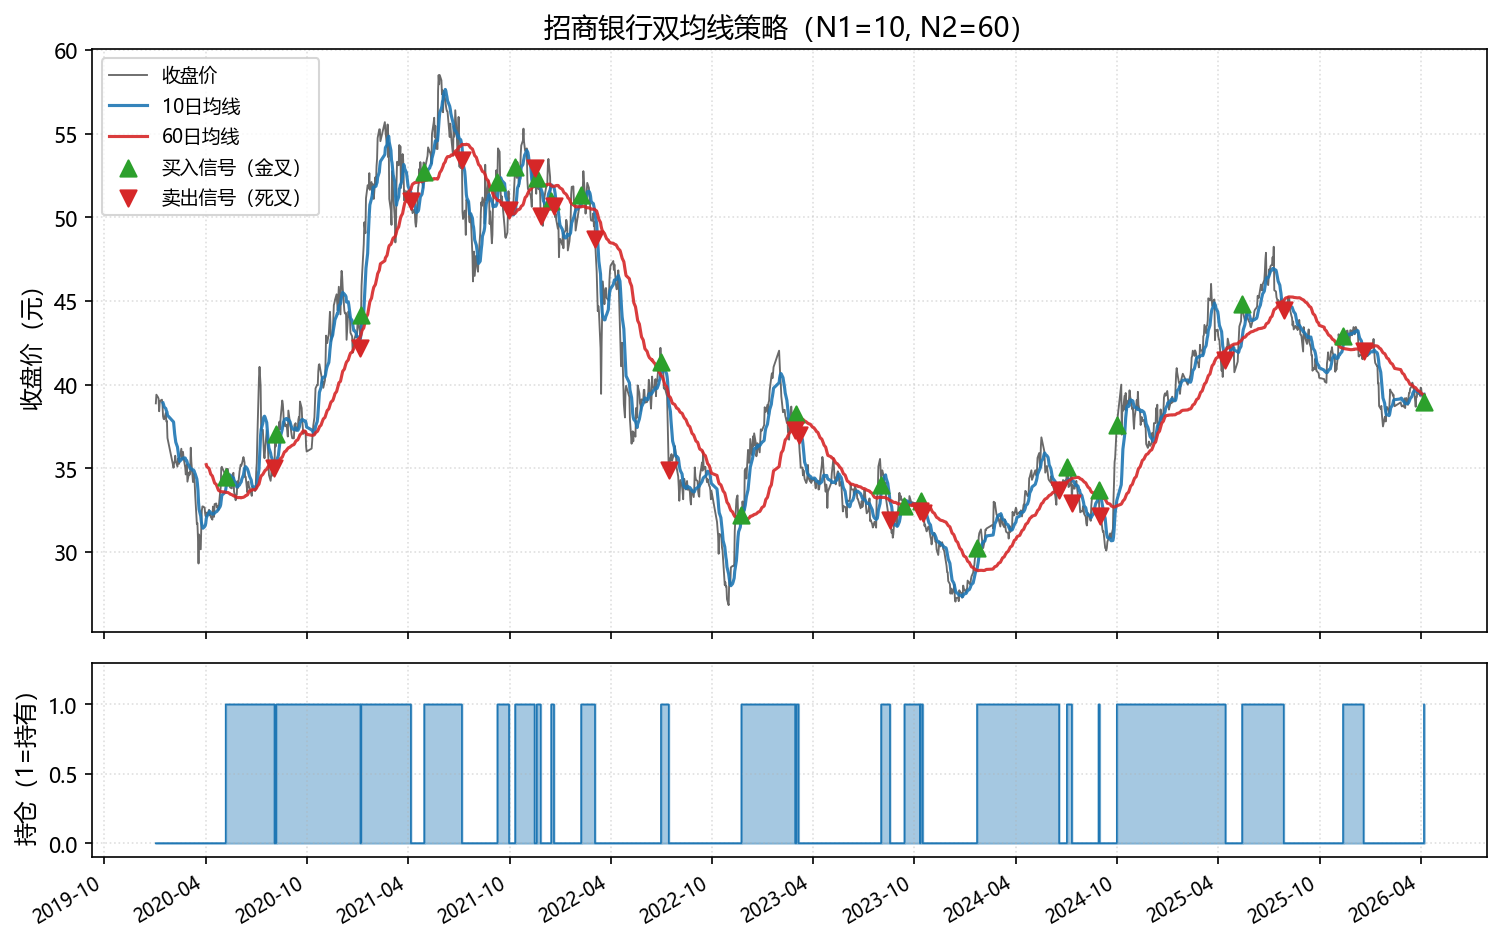

图片已保存：./figs/fig_strategies_02_ma_cross.png


In [26]:
# ------------------------------------------------------------------
# 双均线策略信号可视化（招商银行）
# fig_strategies_02_ma_cross.png
# ------------------------------------------------------------------
N1 = 10   # 短期均线窗口（可调整）
N2 = 60   # 长期均线窗口（可调整）

stock_name = '招商银行'
price = price_dict[stock_name].copy()

# 计算均线
ma_short = price.rolling(N1).mean()
ma_long  = price.rolling(N2).mean()

# 生成信号：短线上穿长线=买入，下穿=卖出
# 注意：用 shift(1) 取前一日状态，避免当日信号用当日数据（未来函数）
cross_up   = (ma_short > ma_long) & (ma_short.shift(1) <= ma_long.shift(1))  # 金叉
cross_down = (ma_short < ma_long) & (ma_short.shift(1) >= ma_long.shift(1))  # 死叉

# 持仓状态（1=持仓，0=空仓），用前向填充维持信号
signal = pd.Series(0, index=price.index)
signal[cross_up]   = 1
signal[cross_down] = -1
position = signal.replace(0, np.nan).ffill().fillna(0).clip(0, 1)

buy_dates  = price.index[cross_up]
sell_dates = price.index[cross_down]
print(f'买入信号：{len(buy_dates)} 次，卖出信号：{len(sell_dates)} 次')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7),
                                gridspec_kw={'height_ratios': [3, 1]},
                                sharex=True)
fig.subplots_adjust(hspace=0.08)

# 子图1：价格 + 均线 + 信号点
ax1.plot(price, color='#444', lw=0.9, label='收盘价', alpha=0.8)
ax1.plot(ma_short, color='#1f77b4', lw=1.5, label=f'{N1}日均线', alpha=0.9)
ax1.plot(ma_long,  color='#d62728', lw=1.5, label=f'{N2}日均线', alpha=0.9)
ax1.scatter(buy_dates,  price[buy_dates],  marker='^', color='#2ca02c',
            s=60, zorder=5, label='买入信号（金叉）')
ax1.scatter(sell_dates, price[sell_dates], marker='v', color='#d62728',
            s=60, zorder=5, label='卖出信号（死叉）')
ax1.set_ylabel('收盘价（元）', fontsize=11)
ax1.legend(fontsize=9, loc='upper left')
ax1.grid(linestyle=':', alpha=0.4)
ax1.set_title(f'{stock_name}双均线策略（N1={N1}, N2={N2}）', fontsize=13)

# 子图2：持仓状态
ax2.fill_between(position.index, position, 0,
                 step='post', alpha=0.4, color='#1f77b4', label='持仓状态')
ax2.plot(position, color='#1f77b4', lw=0.8, drawstyle='steps-post')
ax2.set_ylabel('持仓（1=持有）', fontsize=11)
ax2.set_ylim(-0.1, 1.3)
ax2.grid(linestyle=':', alpha=0.4)

ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=30, ha='right', fontsize=9)

plt.savefig('./figs/fig_strategies_02_ma_cross.png')
plt.show()
print('图片已保存：./figs/fig_strategies_02_ma_cross.png')


=== 最近6个月末动量排名（N=60）===
2025-11-30：招商银行(0.4%)  >  中兴通讯(-4.2%)  >  长城汽车(-14.5%)
2025-12-31：招商银行(3.9%)  >  长城汽车(-8.1%)  >  中兴通讯(-19.1%)
2026-01-31：中兴通讯(-5.5%)  >  长城汽车(-6.3%)  >  招商银行(-11.0%)
2026-02-28：中兴通讯(-0.2%)  >  长城汽车(-4.0%)  >  招商银行(-9.7%)
2026-03-31：招商银行(-5.8%)  >  长城汽车(-8.1%)  >  中兴通讯(-16.1%)
2026-04-30：招商银行(-7.1%)  >  长城汽车(-8.0%)  >  中兴通讯(-15.0%)


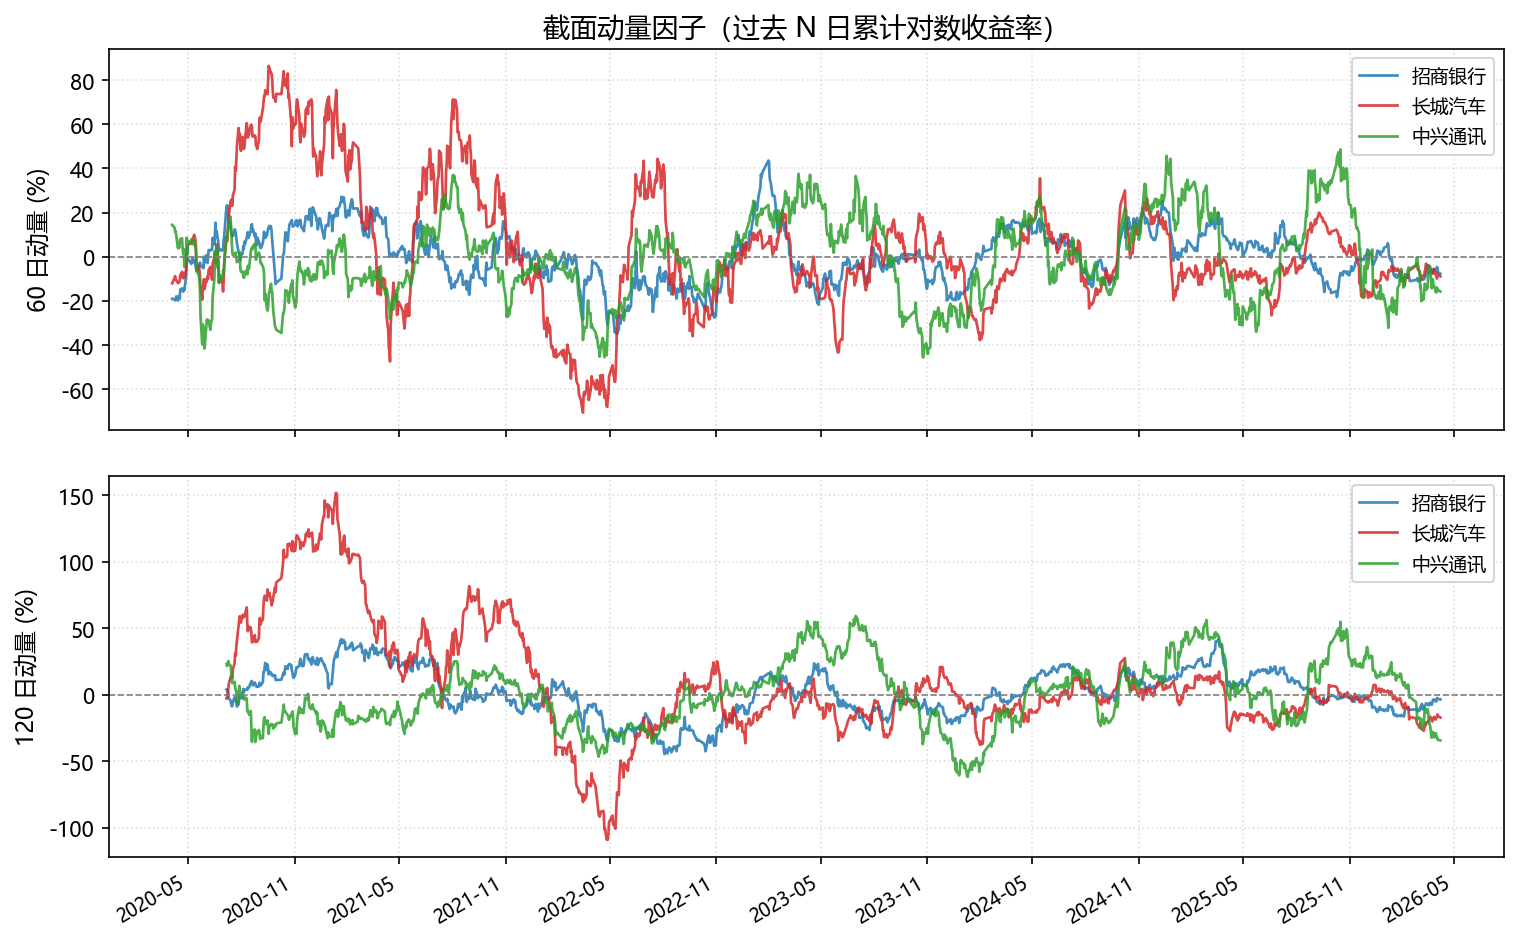

图片已保存：./figs/fig_strategies_03_momentum.png


In [30]:
# ------------------------------------------------------------------
# 截面动量因子：三支股票 N=60 和 N=120 的动量值时序
# fig_strategies_03_momentum.png
# ------------------------------------------------------------------
MOM_WINDOWS = [60, 120]   # 动量窗口（交易日数）

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
fig.subplots_adjust(hspace=0.12)

for ax, N in zip(axes, MOM_WINDOWS):
    for name, color in COLORS.items():
        mom = ret_df[name].rolling(N).sum()  # 累计对数收益率 = 动量因子
        ax.plot(mom.index, mom * 100, color=color, lw=1.3,
                label=name, alpha=0.85)
    ax.axhline(0, color='gray', lw=0.8, ls='--')
    ax.set_ylabel(f'{N} 日动量 (%)', fontsize=11)
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(linestyle=':', alpha=0.4)

axes[0].set_title('截面动量因子（过去 N 日累计对数收益率）', fontsize=13)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=30, ha='right', fontsize=9)

# 月末截面排名变化表格（最近 6 个月末）
month_ends = ret_df.resample('ME').last().index[-6:]
print('\n=== 最近6个月末动量排名（N=60）===')
for dt in month_ends:
    row = {}
    for name in COLORS:
        idx = ret_df.index.get_indexer([dt], method='ffill')[0]
        if idx >= 60:
            row[name] = ret_df[name].iloc[idx-60:idx].sum() * 100
    if row:
        ranked = sorted(row.items(), key=lambda x: -x[1])
        print(f'{dt.date()}：' + '  >  '.join([f'{n}({v:.1f}%)' for n, v in ranked]))

plt.savefig('./figs/fig_strategies_03_momentum.png')
plt.show()
print('图片已保存：./figs/fig_strategies_03_momentum.png')

## 第3节　均值回归策略

生成图：`fig_strategies_04_bollinger.png`、`fig_strategies_05_pairs.png`

买入信号 26 次，平仓信号 26 次


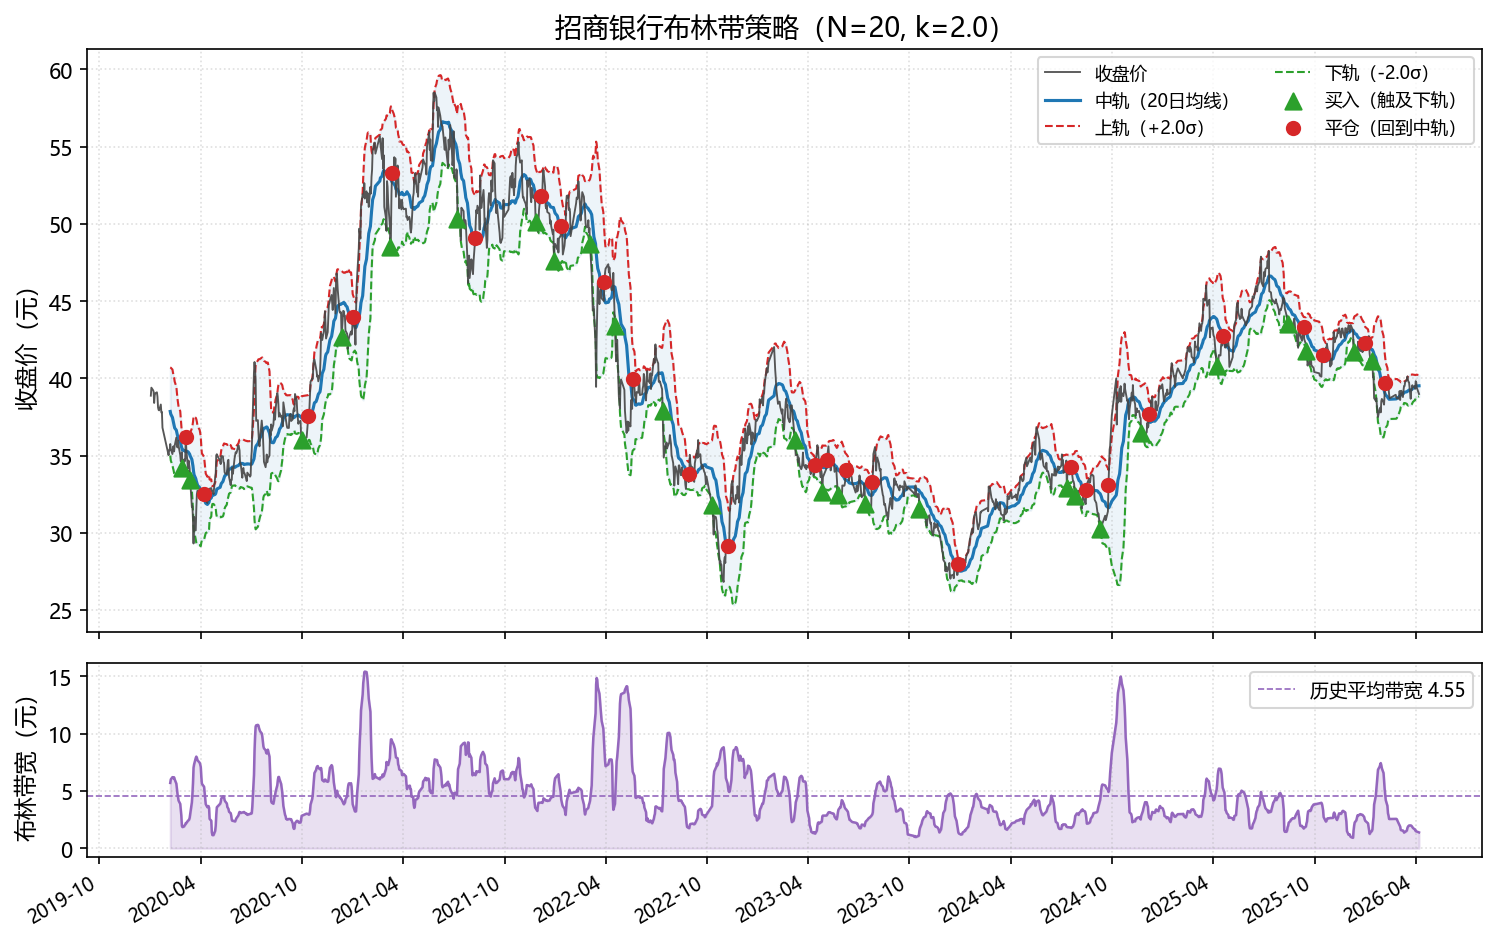

图片已保存：./figs/fig_strategies_04_bollinger.png


In [32]:
# ------------------------------------------------------------------
# 布林带策略可视化（招商银行）
# fig_strategies_04_bollinger.png
# ------------------------------------------------------------------
BB_N = 20   # 布林带均线窗口（可调整）
BB_K = 2.0  # 布林带宽度倍数（可调整）

price = price_dict['招商银行'].copy()

# 计算布林带三条线
bb_mid   = price.rolling(BB_N).mean()                    # 中轨
bb_std   = price.rolling(BB_N).std()                     # 滚动标准差
bb_upper = bb_mid + BB_K * bb_std                        # 上轨
bb_lower = bb_mid - BB_K * bb_std                        # 下轨
bb_width = bb_upper - bb_lower                           # 带宽

# 生成均值回归信号（仅做多版本）
# 价格触及下轨 → 买入；回到中轨以上 → 平仓
in_position = False
entry_dates, exit_dates = [], []

for i in range(BB_N, len(price)):
    p, mid, lower = price.iloc[i], bb_mid.iloc[i], bb_lower.iloc[i]
    if not in_position and p <= lower:
        entry_dates.append(price.index[i])
        in_position = True
    elif in_position and p >= mid:
        exit_dates.append(price.index[i])
        in_position = False

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7),
                                gridspec_kw={'height_ratios': [3, 1]},
                                sharex=True)
fig.subplots_adjust(hspace=0.08)

# 子图1：布林带 + 价格 + 信号
ax1.plot(price, color='#444', lw=0.9, label='收盘价', alpha=0.9, zorder=3)
ax1.plot(bb_mid,   color='#1f77b4', lw=1.5, label=f'中轨（{BB_N}日均线）')
ax1.plot(bb_upper, color='#d62728', lw=1.0, ls='--', label=f'上轨（+{BB_K}σ）')
ax1.plot(bb_lower, color='#2ca02c', lw=1.0, ls='--', label=f'下轨（-{BB_K}σ）')
ax1.fill_between(price.index, bb_lower, bb_upper,
                 alpha=0.08, color='#1f77b4')
if entry_dates:
    ax1.scatter(entry_dates, price[entry_dates], marker='^',
                color='#2ca02c', s=60, zorder=5, label='买入（触及下轨）')
if exit_dates:
    ax1.scatter(exit_dates, price[exit_dates], marker='o',
                color='#d62728', s=40, zorder=5, label='平仓（回到中轨）')
ax1.set_ylabel('收盘价（元）', fontsize=11)
ax1.legend(fontsize=8.5, loc='upper right', ncol=2)
ax1.grid(linestyle=':', alpha=0.4)
ax1.set_title(f'招商银行布林带策略（N={BB_N}, k={BB_K}）', fontsize=13)

# 子图2：带宽变化
ax2.plot(bb_width, color='#9467bd', lw=1.2)
ax2.axhline(bb_width.mean(), color='#9467bd', lw=0.8, ls='--',
            label=f'历史平均带宽 {bb_width.mean():.2f}')
ax2.fill_between(bb_width.index, bb_width, alpha=0.2, color='#9467bd')
ax2.set_ylabel('布林带宽（元）', fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(linestyle=':', alpha=0.4)

ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=30, ha='right', fontsize=9)

print(f'买入信号 {len(entry_dates)} 次，平仓信号 {len(exit_dates)} 次')
plt.savefig('./figs/fig_strategies_04_bollinger.png')
plt.show()
print('图片已保存：./figs/fig_strategies_04_bollinger.png')

In [33]:
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint

# ------------------------------------------------------------------
# 配对交易：协整检验 + 价差可视化
# fig_strategies_05_pairs.png
# ------------------------------------------------------------------
# 使用招商银行和长城汽车进行配对分析
# （实际配对交易应选择行业相近的股票，这里仅作演示）
PAIR_A = '招商银行'
PAIR_B = '长城汽车'

log_A = np.log(price_dict[PAIR_A])
log_B = np.log(price_dict[PAIR_B])

# 对齐日期
common = log_A.index.intersection(log_B.index)
log_A  = log_A[common]
log_B  = log_B[common]

# 协整检验（Engle-Granger 两步法）
coint_stat, coint_pval, crit_vals = coint(log_A, log_B)
print(f'=== 协整检验：{PAIR_A} vs {PAIR_B} ===')
print(f'检验统计量：{coint_stat:.4f}')
print(f'p 值：{coint_pval:.4f}')
print(f'临界值（1%/5%/10%）：{np.round(crit_vals, 4)}')
if coint_pval < 0.05:
    print('结论：两支股票存在协整关系（p < 0.05）')
else:
    print('结论：未发现显著协整关系（p >= 0.05），价差可能不平稳')
    print('注：这在实际中很常见，配对交易需要仔细筛选股票对')

# 估计协整系数 β：OLS 回归 ln(A) 对 ln(B)
X = sm.add_constant(log_B)
ols_res = sm.OLS(log_A, X).fit()
beta = ols_res.params.iloc[1]
print(f'\n协整系数 β = {beta:.4f}，R² = {ols_res.rsquared:.4f}')

# 计算价差
spread = log_A - beta * log_B
spread_mean = spread.rolling(60).mean()   # 滚动均值（60日）
spread_std  = spread.rolling(60).std()    # 滚动标准差
z_score = (spread - spread_mean) / spread_std  # 标准化价差

=== 协整检验：招商银行 vs 长城汽车 ===
检验统计量：-2.3475
p 值：0.3501
临界值（1%/5%/10%）：[-3.9037 -3.3402 -3.0473]
结论：未发现显著协整关系（p >= 0.05），价差可能不平稳
注：这在实际中很常见，配对交易需要仔细筛选股票对

协整系数 β = 0.1939，R² = 0.2371



信号统计：买入信号（z<-2）108 次，做空信号（z>2）83 次


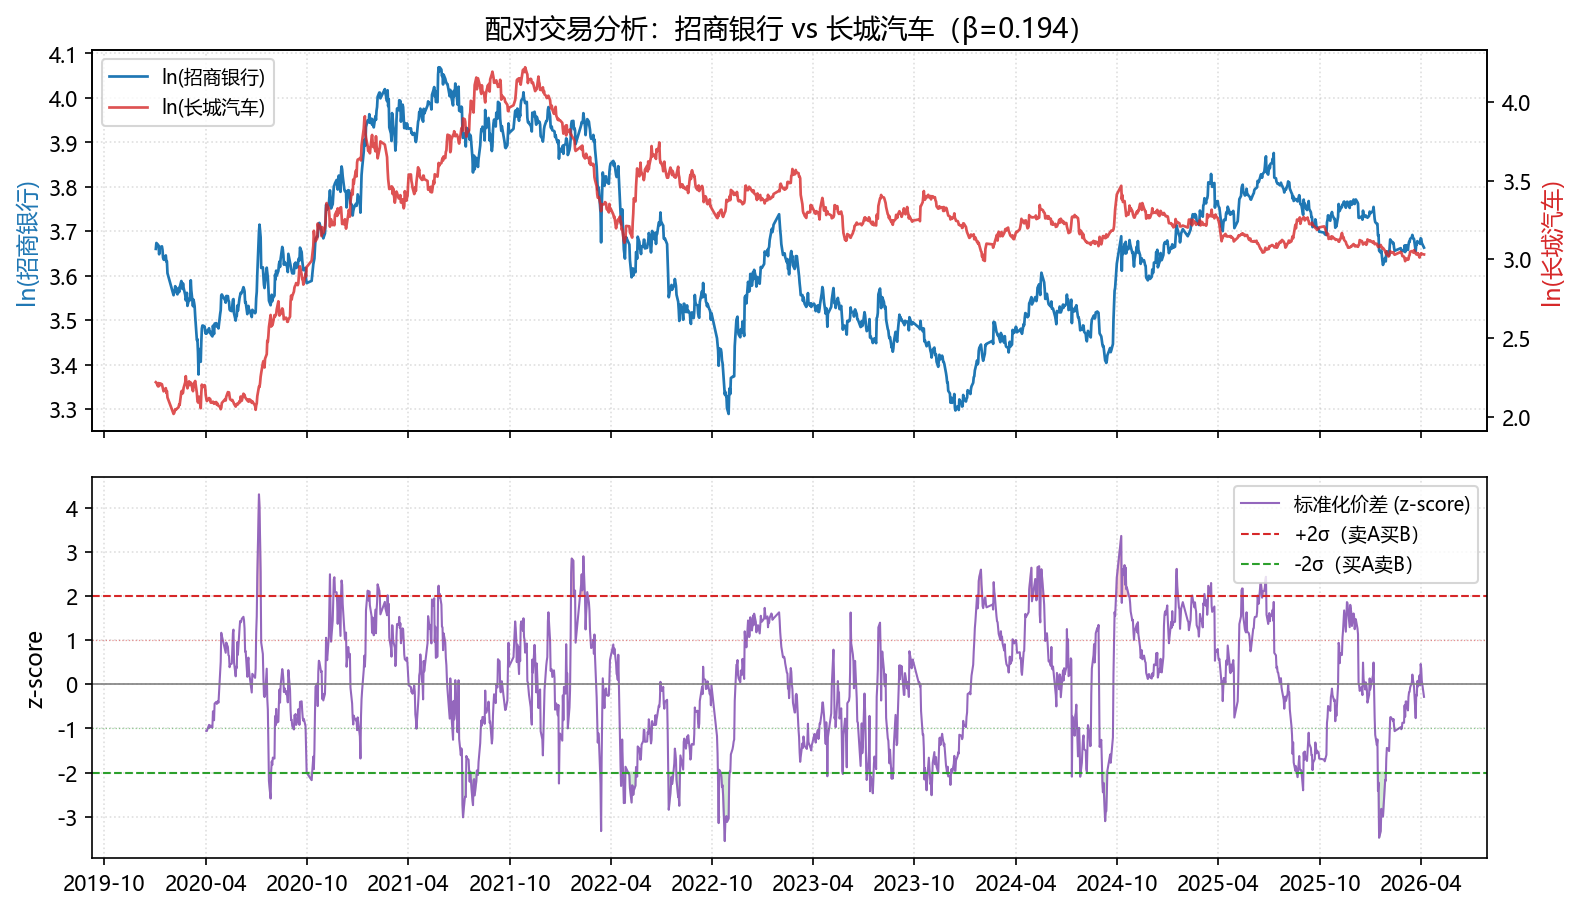

图片已保存：./figs/fig_strategies_05_pairs.png


In [34]:
# 绘图
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
fig.subplots_adjust(hspace=0.12)

# 子图1：两支股票对数价格走势（双轴）
ax1_r = ax1.twinx()
l1, = ax1.plot(log_A, color='#1f77b4', lw=1.3, label=f'ln({PAIR_A})')
l2, = ax1_r.plot(log_B, color='#d62728', lw=1.3, label=f'ln({PAIR_B})', alpha=0.8)
ax1.set_ylabel(f'ln({PAIR_A})', fontsize=11, color='#1f77b4')
ax1_r.set_ylabel(f'ln({PAIR_B})', fontsize=11, color='#d62728')
ax1.legend(handles=[l1, l2], fontsize=9, loc='upper left')
ax1.grid(linestyle=':', alpha=0.4)
ax1.set_title(f'配对交易分析：{PAIR_A} vs {PAIR_B}（β={beta:.3f}）', fontsize=13)

# 子图2：标准化价差 + 阈值线
ax2.plot(z_score, color='#9467bd', lw=1.0, label='标准化价差 (z-score)')
ax2.axhline(0,   color='gray',    lw=0.8, ls='-')
ax2.axhline(2,   color='#d62728', lw=1.0, ls='--', label='+2σ（卖A买B）')
ax2.axhline(-2,  color='#2ca02c', lw=1.0, ls='--', label='-2σ（买A卖B）')
ax2.axhline(1,   color='#d62728', lw=0.6, ls=':', alpha=0.5)
ax2.axhline(-1,  color='#2ca02c', lw=0.6, ls=':', alpha=0.5)

# 标注超买超卖区域
ax2.fill_between(z_score.index, z_score, 2,
                 where=(z_score > 2), alpha=0.2, color='#d62728')
ax2.fill_between(z_score.index, z_score, -2,
                 where=(z_score < -2), alpha=0.2, color='#2ca02c')

ax2.set_ylabel('z-score', fontsize=11)
ax2.legend(fontsize=9, loc='upper right')
ax2.grid(linestyle=':', alpha=0.4)

# 统计信号次数
n_long  = (z_score < -2).sum()
n_short = (z_score >  2).sum()
print(f'\n信号统计：买入信号（z<-2）{n_long} 次，做空信号（z>2）{n_short} 次')

ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=30, ha='right', fontsize=9)

plt.savefig('./figs/fig_strategies_05_pairs.png')
plt.show()
print('图片已保存：./figs/fig_strategies_05_pairs.png')

## 第4节　因子选股

生成图：`fig_strategies_06_value_factor.png`、`fig_strategies_07_multifactor.png`

=== 行业中性化后各分组平均原始 P/B ===
group
Q1（最低）    1.696
Q2        1.922
Q3        2.187
Q4        3.116
Q5（最高）    4.080
Name: PB_winsor, dtype: float64


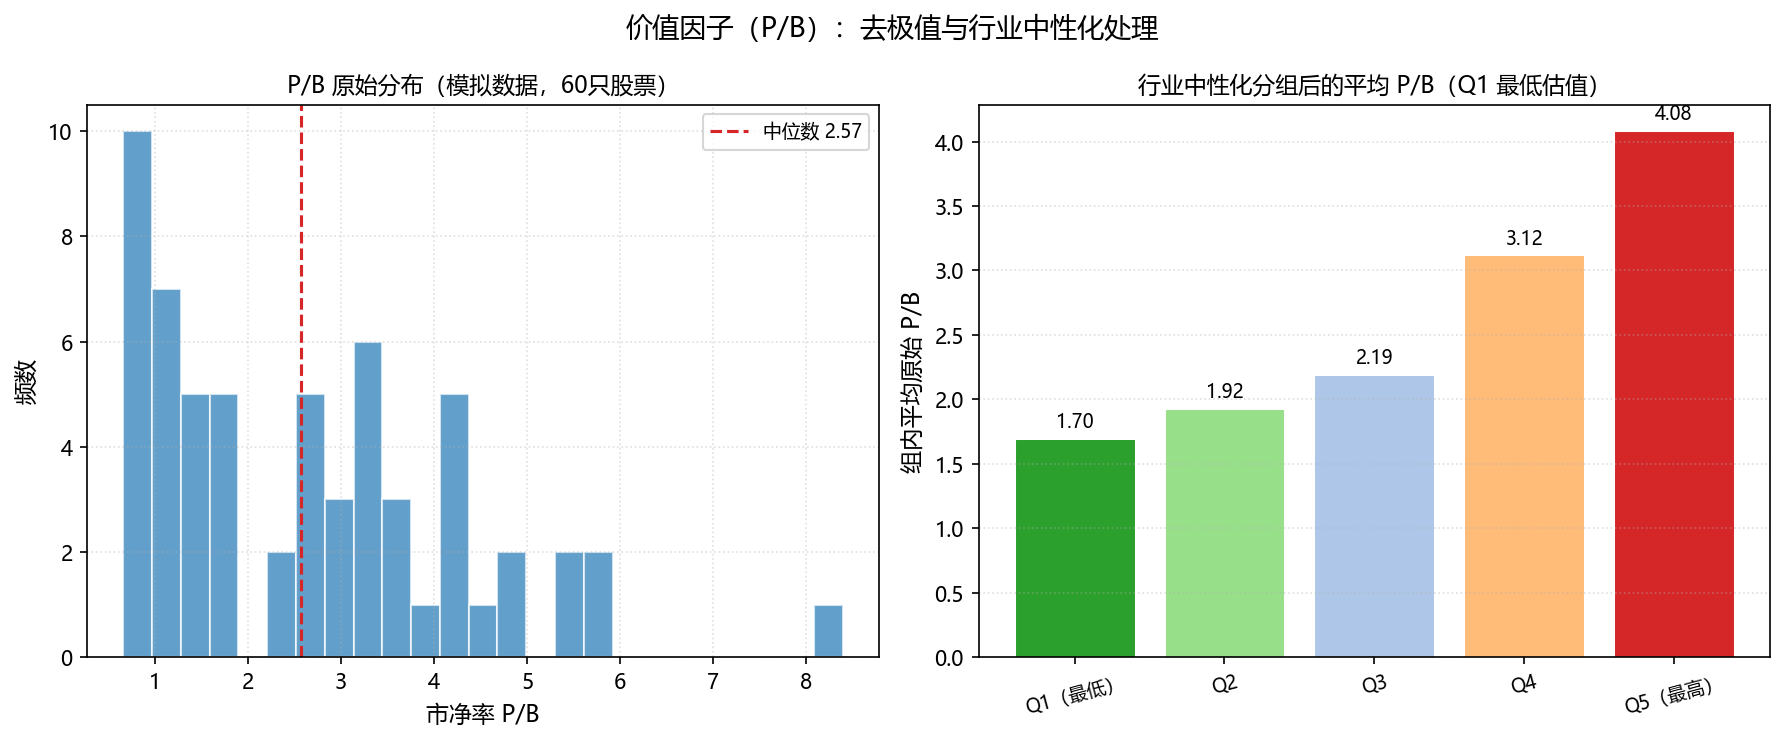

图片已保存：./figs/fig_strategies_06_value_factor.png


In [35]:
# ------------------------------------------------------------------
# 价值因子模拟示例（行业中性化演示）
# 使用模拟数据演示去极值与行业中性化的完整流程
# fig_strategies_06_value_factor.png
# ------------------------------------------------------------------
np.random.seed(42)

N_STOCKS    = 60
INDUSTRIES  = ['银行', '汽车', '科技', '消费', '医药']
stocks_per  = N_STOCKS // len(INDUSTRIES)

# 模拟截面数据
industry_col = [ind for ind in INDUSTRIES for _ in range(stocks_per)]
# 不同行业的 P/B 均值不同（银行低，科技高）
ind_means = {'银行': 0.8, '汽车': 1.5, '科技': 4.0, '消费': 3.2, '医药': 3.8}
pb_raw = []
for ind in industry_col:
    mu  = ind_means[ind]
    val = np.random.lognormal(np.log(mu), 0.4)  # 对数正态分布模拟 P/B
    pb_raw.append(val)

df_sim = pd.DataFrame({'industry': industry_col, 'PB': pb_raw})

# 1. 去极值（Winsorize：上下 5% 截断）
lo, hi = df_sim['PB'].quantile(0.05), df_sim['PB'].quantile(0.95)
df_sim['PB_winsor'] = df_sim['PB'].clip(lo, hi)

# 2. 行业内标准化（z-score）
def ind_zscore(group):
    mu  = group['PB_winsor'].mean()
    std = group['PB_winsor'].std()
    group['PB_neutral'] = (group['PB_winsor'] - mu) / (std + 1e-8)
    return group

df_sim = df_sim.groupby('industry', group_keys=False).apply(ind_zscore)

# 3. 分组（5组，按行业中性化 P/B 排名）
df_sim['group'] = pd.qcut(df_sim['PB_neutral'], q=5,
                           labels=['Q1（最低）','Q2','Q3','Q4','Q5（最高）'])

group_mean = df_sim.groupby('group', observed=True)['PB_winsor'].mean()
print('=== 行业中性化后各分组平均原始 P/B ===')
print(group_mean.round(3))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 子图1：P/B 原始分布
ax1.hist(df_sim['PB'], bins=25, color='#1f77b4', alpha=0.7, edgecolor='white')
ax1.axvline(df_sim['PB'].median(), color='#d62728', lw=1.5, ls='--',
            label=f'中位数 {df_sim["PB"].median():.2f}')
ax1.set_xlabel('市净率 P/B', fontsize=11)
ax1.set_ylabel('频数', fontsize=11)
ax1.set_title('P/B 原始分布（模拟数据，60只股票）', fontsize=11)
ax1.legend(fontsize=9)
ax1.grid(linestyle=':', alpha=0.4)

# 子图2：行业中性化后各分组均值
colors_bar = ['#2ca02c','#98df8a','#aec7e8','#ffbb78','#d62728']
bars = ax2.bar(range(len(group_mean)), group_mean.values,
               color=colors_bar, edgecolor='white', linewidth=0.5)
ax2.set_xticks(range(len(group_mean)))
ax2.set_xticklabels(group_mean.index, fontsize=9, rotation=15)
ax2.set_ylabel('组内平均原始 P/B', fontsize=11)
ax2.set_title('行业中性化分组后的平均 P/B（Q1 最低估值）', fontsize=11)
for bar, val in zip(bars, group_mean.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{val:.2f}', ha='center', va='bottom', fontsize=9)
ax2.grid(axis='y', linestyle=':', alpha=0.4)

plt.suptitle('价值因子（P/B）：去极值与行业中性化处理', fontsize=13)
plt.tight_layout()
plt.savefig('./figs/fig_strategies_06_value_factor.png')
plt.show()
print('图片已保存：./figs/fig_strategies_06_value_factor.png')

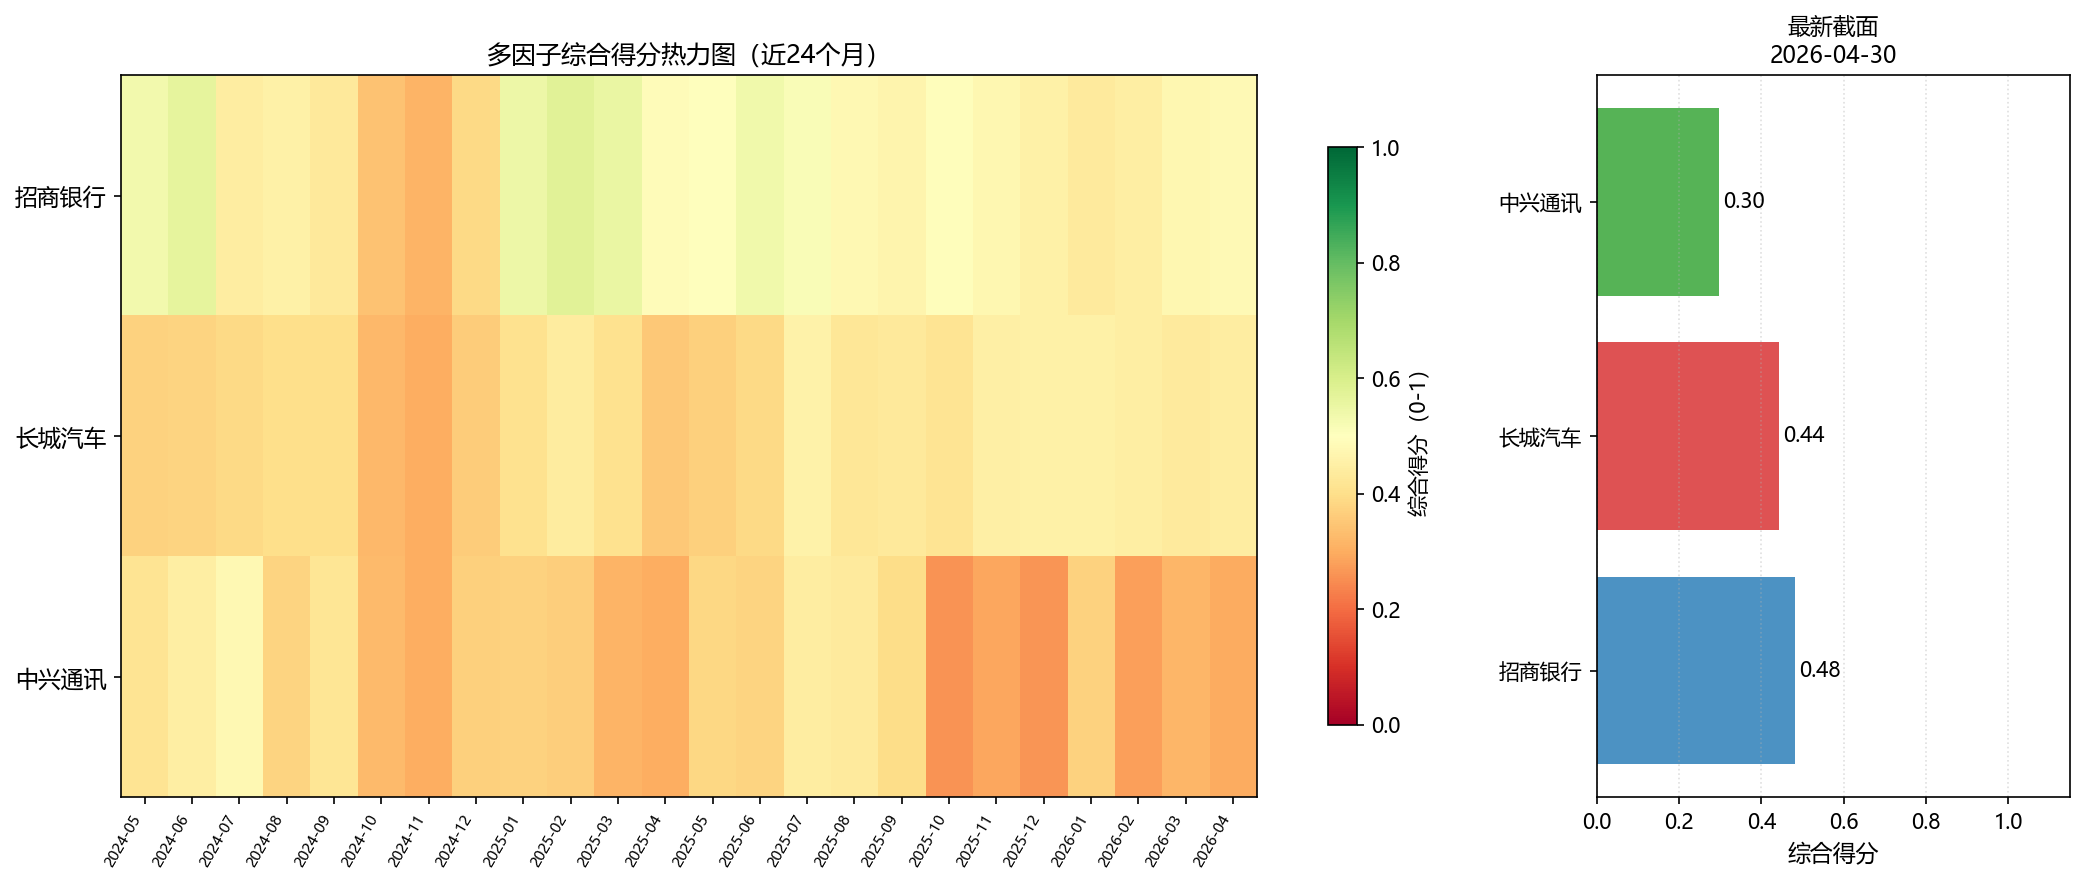

图片已保存：./figs/fig_strategies_07_multifactor.png


In [36]:
# ------------------------------------------------------------------
# 多因子打分体系：三支股票的动量 + 低波动 + 假设价值因子
# 在月末截面计算，用热力图展示得分动态
# fig_strategies_07_multifactor.png
# ------------------------------------------------------------------
# 假设的 P/B（行业中性化后，固定值演示）
# 实际应用中应从财务数据中获取实时值
PB_ASSUMED = {'招商银行': 0.8, '长城汽车': 2.1, '中兴通讯': 1.4}
MOM_WIN    = 120   # 动量窗口
VOL_WIN    = 60    # 波动率窗口

# 获取所有月末日期
month_ends = ret_df.resample('ME').last().index

records = []
for dt in month_ends:
    idx = ret_df.index.get_indexer([dt], method='ffill')[0]
    if idx < max(MOM_WIN, VOL_WIN):
        continue
    row = {'日期': dt}
    for name in COLORS:
        r = ret_df[name]
        # 动量因子（过去 MOM_WIN 日累计收益）
        mom = r.iloc[idx - MOM_WIN: idx].sum()
        # 低波动因子（取负值，使低波动=高得分）
        vol = -r.iloc[idx - VOL_WIN: idx].std() * np.sqrt(TRADING_DAYS)
        # 价值因子（P/B 取负，使低 P/B = 高得分）
        val = -PB_ASSUMED[name]
        row[f'{name}_动量'] = mom
        row[f'{name}_低波动'] = vol
        row[f'{name}_价值'] = val
    records.append(row)

score_df = pd.DataFrame(records).set_index('日期')

# Min-Max 标准化（0-1）并计算综合得分
factor_names = ['动量', '低波动', '价值']
composite = pd.DataFrame(index=score_df.index)

for name in COLORS:
    scores = []
    for factor in factor_names:
        col = score_df[f'{name}_{factor}']
        # Min-Max 标准化
        normed = (col - col.min()) / (col.max() - col.min() + 1e-8)
        scores.append(normed)
    composite[name] = sum(scores) / len(scores)  # 等权综合

# 绘制热力图：横轴股票，纵轴月份，颜色=综合得分
plot_data = composite.tail(24).T  # 展示最近 24 个月

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6),
                                gridspec_kw={'width_ratios': [3, 1]})

import matplotlib.colors as mcolors
im = ax1.imshow(plot_data.values, cmap='RdYlGn', aspect='auto',
                vmin=0, vmax=1)
ax1.set_xticks(range(len(plot_data.columns)))
ax1.set_xticklabels([str(d)[:7] for d in plot_data.columns],
                    rotation=60, ha='right', fontsize=7)
ax1.set_yticks(range(len(plot_data.index)))
ax1.set_yticklabels(plot_data.index, fontsize=11)
ax1.set_title('多因子综合得分热力图（近24个月）', fontsize=12)
plt.colorbar(im, ax=ax1, label='综合得分（0-1）', shrink=0.8)

# 最新截面因子分项得分柱状图
latest = composite.iloc[-1]
bars = ax2.barh(list(latest.index), list(latest.values),
                color=[COLORS[n] for n in latest.index], alpha=0.8)
for bar, val in zip(bars, latest.values):
    ax2.text(val + 0.01, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}', va='center', fontsize=10)
ax2.set_xlim(0, 1.15)
ax2.set_xlabel('综合得分', fontsize=11)
ax2.set_title(f'最新截面\n{composite.index[-1].date()}', fontsize=11)
ax2.grid(axis='x', linestyle=':', alpha=0.4)

plt.tight_layout()
plt.savefig('./figs/fig_strategies_07_multifactor.png')
plt.show()
print('图片已保存：./figs/fig_strategies_07_multifactor.png')

## 第5节　多因子模型：IC 评价

生成图：`fig_strategies_08_multifactor_flow.png`、`fig_strategies_09_ic.png`

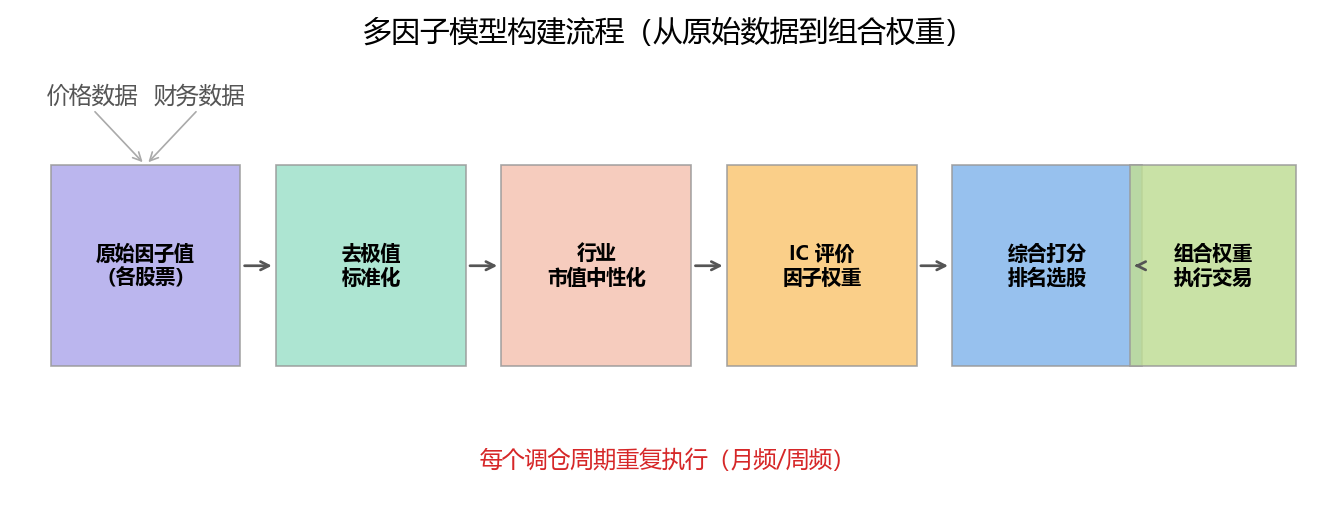

图片已保存：./figs/fig_strategies_08_multifactor_flow.png


In [ ]:
# ------------------------------------------------------------------
# 多因子流程图（纯示意）
# fig_strategies_08_multifactor_flow.png
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 4))
ax.set_xlim(0, 11)
ax.set_ylim(0, 4)
ax.axis('off')

steps = [
    ('原始因子值\n（各股票）', '#AFA9EC', 1.1),
    ('去极值\n标准化', '#9FE1CB', 3.0),
    ('行业\n市值中性化', '#F5C4B3', 4.9),
    ('IC 评价\n因子权重', '#FAC775', 6.8),
    ('综合打分\n排名选股', '#85B7EB', 8.7),
    ('组合权重\n执行交易', '#C0DD97', 10.1),
]
for label, color, cx in steps:
    w = 1.6 if cx < 10 else 1.4
    rect = plt.Rectangle((cx - w/2, 1.2), w, 1.6, linewidth=0.8,
                          edgecolor='#999', facecolor=color, alpha=0.85, zorder=2)
    ax.add_patch(rect)
    ax.text(cx, 2.0, label, ha='center', va='center',
            fontsize=9.5, fontweight='bold', zorder=3)

# 箭头
arrow_xs = [(1.9, 2.2), (3.8, 4.1), (5.7, 6.0), (7.6, 7.9), (9.5, 9.4)]
for x1, x2 in arrow_xs:
    ax.annotate('', xy=(x2, 2.0), xytext=(x1, 2.0),
                arrowprops=dict(arrowstyle='->', color='#555', lw=1.3))

# 数据输入标注
for label, cx in [('价格数据', 1.1), ('财务数据', 2.0)]:
    ax.text(cx - 0.45, 3.3, label, ha='center', fontsize=11, color='#555', style='italic')
    ax.annotate('', xy=(1.1, 2.8), xytext=(cx - 0.45, 3.25),
                arrowprops=dict(arrowstyle='->', color='#aaa', lw=0.8))

ax.text(5.5, 0.5, '每个调仓周期重复执行（月频/周频）',
        ha='center', fontsize=11, color='#d62728', style='italic')

fig.suptitle('多因子模型构建流程（从原始数据到组合权重）', fontsize=14, y=0.87)
plt.tight_layout()
plt.savefig('./figs/fig_strategies_08_multifactor_flow.png', bbox_inches='tight')
plt.show()
print('图片已保存：./figs/fig_strategies_08_multifactor_flow.png')

=== 动量因子 IC 统计（N=60日, 持有期≈1个月）===
IC 均值：-0.0974
IC 标准差：0.7466
ICIR：-0.1305
正 IC 月份占比：42.3%

注：截面仅3支股票，IC 估计噪声极大，仅作演示。
实际应用中需要 50 只以上股票才能得到稳健的 IC 估计。


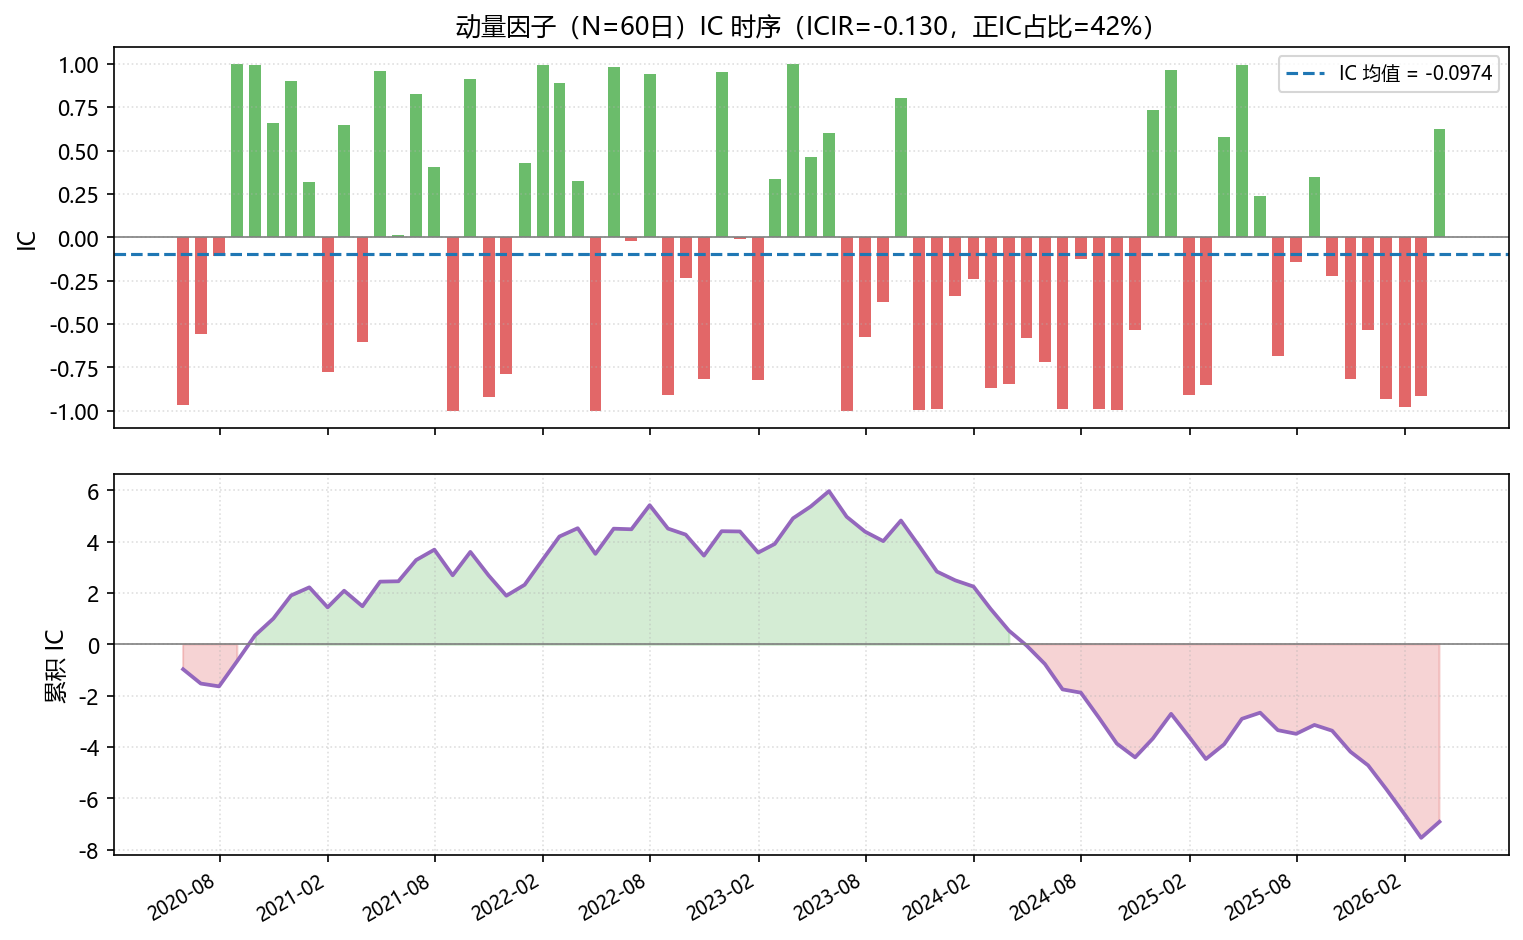

图片已保存：./figs/fig_strategies_09_ic.png


In [89]:
# ------------------------------------------------------------------
# 动量因子 IC 时序计算与可视化
# fig_strategies_09_ic.png
# 注：三支股票的截面太小，IC 噪声很大，这是正常的
# 实际应用需要 50 只以上股票才能得到稳健的 IC 估计
# ------------------------------------------------------------------
from scipy.stats import pearsonr

IC_MOM_WIN   = 60    # 动量因子计算窗口（交易日）
IC_HOLD_DAYS = 21    # 预测持有期（约1个月）

# 在月末截面计算动量因子和下期实际收益
month_ends = ret_df.resample('ME').last().index
ic_records = []

for i, dt in enumerate(month_ends[:-1]):  # 最后一期无法计算下期收益
    idx = ret_df.index.get_indexer([dt], method='ffill')[0]
    if idx < IC_MOM_WIN + IC_HOLD_DAYS:
        continue

    # 当期因子值：过去 IC_MOM_WIN 日累计收益
    factor_vals = {}
    future_rets = {}
    for name in COLORS:
        factor_vals[name] = ret_df[name].iloc[idx - IC_MOM_WIN: idx].sum()
        # 下期实际收益：下一个月末的累计收益
        next_dt = month_ends[i + 1]
        next_idx = ret_df.index.get_indexer([next_dt], method='ffill')[0]
        future_rets[name] = ret_df[name].iloc[idx: next_idx].sum()

    # 只有3个数据点，Pearson 相关可能不稳定，仍作演示
    fv = list(factor_vals.values())
    fr = list(future_rets.values())
    if len(set(fv)) > 1:  # 因子值不全相同
        r, _ = pearsonr(fv, fr)
        ic_records.append({'日期': dt, 'IC': r})

ic_df = pd.DataFrame(ic_records).set_index('日期')

# IC 统计量
ic_mean = ic_df['IC'].mean()
ic_std  = ic_df['IC'].std()
icir    = ic_mean / ic_std if ic_std > 0 else np.nan
pos_pct = (ic_df['IC'] > 0).mean()

print(f'=== 动量因子 IC 统计（N={IC_MOM_WIN}日, 持有期≈1个月）===')
print(f'IC 均值：{ic_mean:.4f}')
print(f'IC 标准差：{ic_std:.4f}')
print(f'ICIR：{icir:.4f}')
print(f'正 IC 月份占比：{pos_pct:.1%}')
print(f'\n注：截面仅3支股票，IC 估计噪声极大，仅作演示。')
print('实际应用中需要 50 只以上股票才能得到稳健的 IC 估计。')

# 绘图
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
fig.subplots_adjust(hspace=0.12)

# IC 柱状图
colors_ic = ['#2ca02c' if v > 0 else '#d62728' for v in ic_df['IC']]
ax1.bar(ic_df.index, ic_df['IC'], color=colors_ic, alpha=0.7, width=20)
ax1.axhline(ic_mean, color='#1f77b4', lw=1.5, ls='--',
            label=f'IC 均值 = {ic_mean:.4f}')
ax1.axhline(0, color='gray', lw=0.8)
ax1.set_ylabel('IC', fontsize=11)
ax1.legend(fontsize=9)
ax1.grid(axis='y', linestyle=':', alpha=0.4)
ax1.set_title(f'动量因子（N={IC_MOM_WIN}日）IC 时序（ICIR={icir:.3f}，正IC占比={pos_pct:.0%}）', fontsize=12)

# 累积 IC
ic_cumsum = ic_df['IC'].cumsum()
ax2.plot(ic_cumsum, color='#9467bd', lw=1.8)
ax2.fill_between(ic_cumsum.index, ic_cumsum, 0,
                 where=(ic_cumsum >= 0), alpha=0.2, color='#2ca02c')
ax2.fill_between(ic_cumsum.index, ic_cumsum, 0,
                 where=(ic_cumsum < 0), alpha=0.2, color='#d62728')
ax2.axhline(0, color='gray', lw=0.8)
ax2.set_ylabel('累积 IC', fontsize=11)
ax2.grid(linestyle=':', alpha=0.4)

ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=30, ha='right', fontsize=9)

plt.savefig('./figs/fig_strategies_09_ic.png')
plt.show()
print('图片已保存：./figs/fig_strategies_09_ic.png')

## 第7节　综合案例：三支股票双均线策略回测

生成图：`fig_strategies_11_bt_comparison.png`

In [ ]:
#!pip install vectorbt

In [100]:
# ------------------------------------------------------------------
# vectorbt 三支股票双均线策略完整回测对比
# ------------------------------------------------------------------
try:
    import vectorbt as vbt
    VBT_AVAILABLE = True
    print('vectorbt 已安装')
except ImportError:
    VBT_AVAILABLE = False
    print('vectorbt 未安装，请运行：pip install vectorbt')
    print('以下单元格将使用手动回测替代，结果一致。')

vectorbt 已安装


In [101]:
# ------------------------------------------------------------------
# 回测参数（统一在顶部定义，方便调整）
# ------------------------------------------------------------------
MA_N1       = 10        # 短期均线（可调整）
MA_N2       = 60        # 长期均线（可调整）
INIT_CASH   = 1_000_000 # 初始资金

results = {}

for name in COLORS:
    price = price_dict[name].copy()

    # 计算均线和信号
    ma_s = price.rolling(MA_N1).mean()
    ma_l = price.rolling(MA_N2).mean()

    # 金叉/死叉（shift(1) 确保用前一日状态，避免未来函数）
    entries = (ma_s > ma_l) & (ma_s.shift(1) <= ma_l.shift(1))
    exits   = (ma_s < ma_l) & (ma_s.shift(1) >= ma_l.shift(1))

    if VBT_AVAILABLE:
        pf = vbt.Portfolio.from_signals(
            price, entries, exits,
            init_cash=INIT_CASH,
            fees=FEES,
            slippage=SLIPPAGE,
        )
        stats = pf.stats()
        nav   = pf.value() / INIT_CASH  # 策略净值
        results[name] = {
            'portfolio': pf,
            'nav':       nav,
            'stats':     stats,
        }
    else:
        # 手动向量化回测（替代 vectorbt）
        pos = entries.astype(int) - exits.astype(int)
        pos = pos.replace(0, np.nan).ffill().fillna(0).clip(0, 1).shift(1).fillna(0)
        daily_ret = price.pct_change()
        # 简化：不计手续费
        strat_ret = (pos * daily_ret).fillna(0)
        nav = (1 + strat_ret).cumprod()
        results[name] = {'nav': nav, 'stats': None}

    # 买入持有基准净值
    bnh_nav = price / price.iloc[0]
    results[name]['bnh_nav'] = bnh_nav

print('回测完成')

回测完成


In [106]:
# ------------------------------------------------------------------
# 打印绩效对比表
# ------------------------------------------------------------------
def calc_stats(nav_series, rf_annual=RF_ANNUAL):
    """从净值序列手动计算关键绩效指标"""
    ret = nav_series.pct_change().dropna()
    annual_ret = ret.mean() * TRADING_DAYS
    annual_std = ret.std()  * np.sqrt(TRADING_DAYS)
    sharpe     = (annual_ret - rf_annual) / annual_std if annual_std > 0 else np.nan
    peak       = nav_series.cummax()
    mdd        = ((nav_series - peak) / peak).min()
    total_ret  = nav_series.iloc[-1] / nav_series.iloc[0] - 1
    return {'年化收益率': f'{annual_ret*100:.1f}%',
            '年化波动率': f'{annual_std*100:.1f}%',
            '最大回撤':   f'{mdd*100:.1f}%',
            '夏普比率':   f'{sharpe:.3f}',
            '区间总收益': f'{total_ret*100:.1f}%'}

rows = []
for name in COLORS:
    strat_s = calc_stats(results[name]['nav'])
    bnh_s   = calc_stats(results[name]['bnh_nav'])
    rows.append({'股票': name, '类型': '均线策略', **strat_s})
    rows.append({'股票': name, '类型': '   买入持有', **bnh_s})

perf_df = pd.DataFrame(rows).set_index(['股票', '类型'])
print('=== 双均线策略 vs 买入持有：绩效对比（手续费0.2%，滑点0.1%）===')
print(perf_df.to_string())

=== 双均线策略 vs 买入持有：绩效对比（手续费0.2%，滑点0.1%）===
              年化收益率  年化波动率    最大回撤    夏普比率   区间总收益
股票   类型                                           
招商银行 均线策略      1.1%  19.6%  -40.1%  -0.048   -5.0%
        买入持有   4.0%  28.2%  -54.2%   0.071    0.3%
长城汽车 均线策略     17.1%  34.6%  -67.6%   0.436   95.6%
        买入持有  23.8%  45.6%  -70.8%   0.478  125.1%
中兴通讯 均线策略      5.7%  29.7%  -43.1%   0.123    8.1%
        买入持有   7.6%  42.8%  -62.8%   0.130   -8.8%


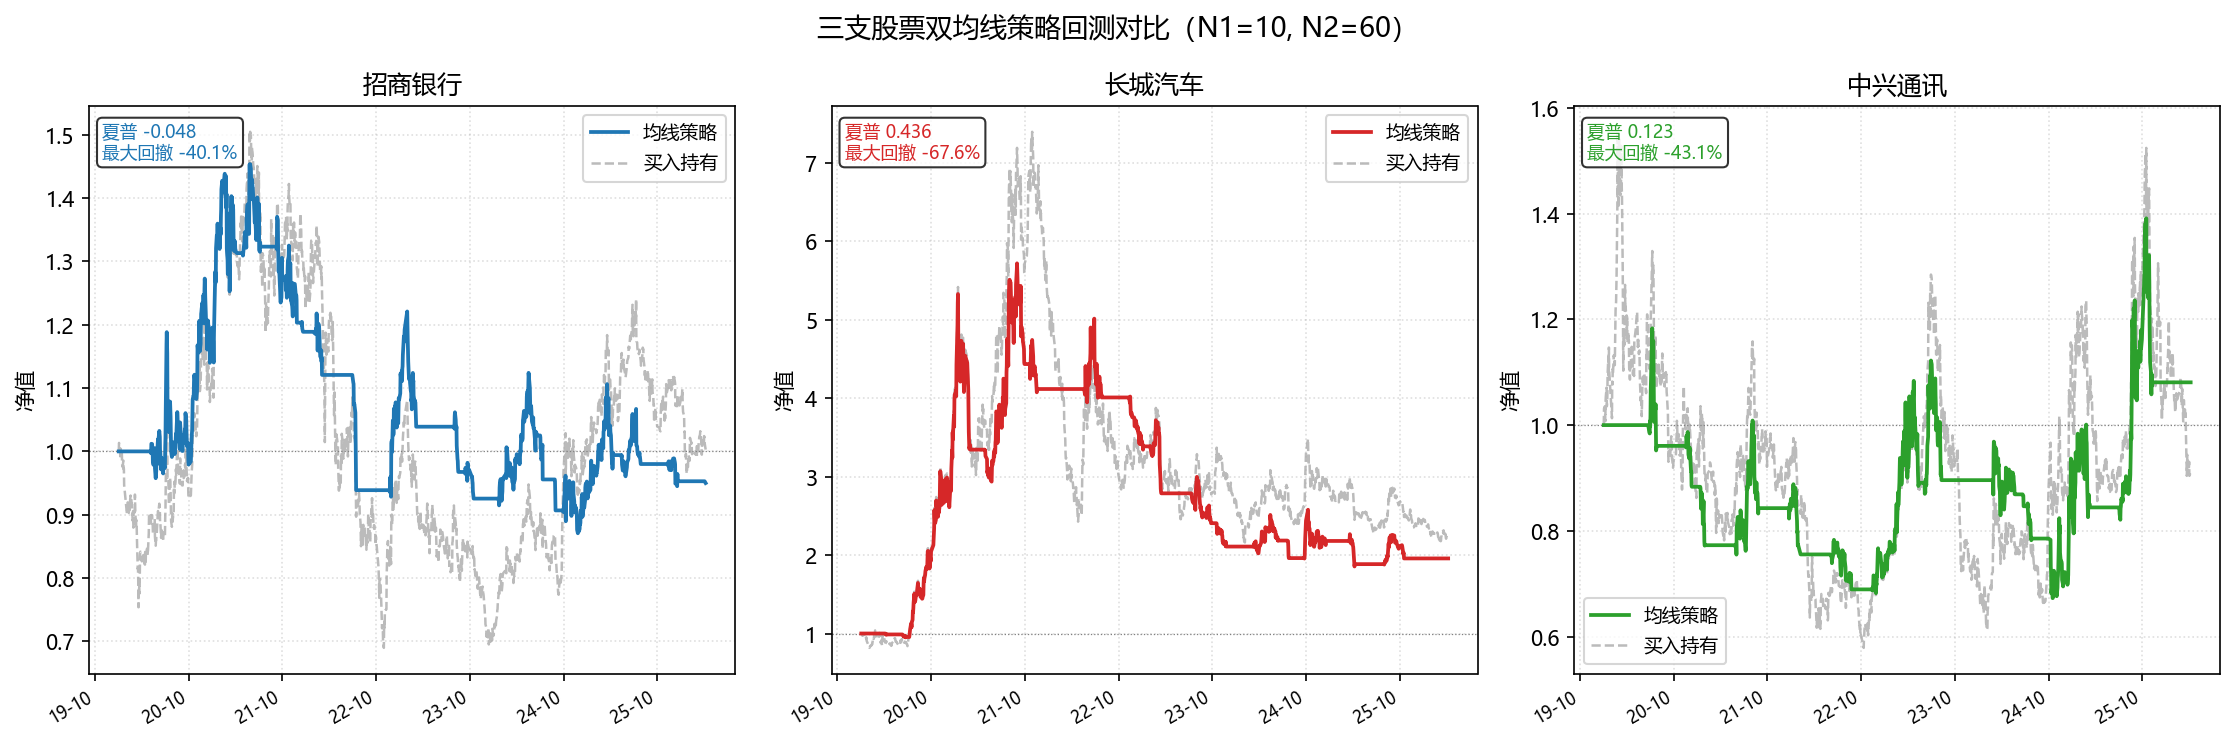

图片已保存：./figs/fig_strategies_11_bt_comparison.png


In [107]:
# ------------------------------------------------------------------
# 绘图：净值对比
# fig_strategies_11_bt_comparison.png
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)
fig.suptitle(f'三支股票双均线策略回测对比（N1={MA_N1}, N2={MA_N2}）', fontsize=13)

for ax, name in zip(axes, COLORS):
    color = COLORS[name]
    nav     = results[name]['nav']
    bnh_nav = results[name]['bnh_nav']

    ax.plot(nav.index,     nav,     color=color,   lw=1.8, label='均线策略', zorder=3)
    ax.plot(bnh_nav.index, bnh_nav, color='#aaa',  lw=1.2, ls='--',
            label='买入持有', alpha=0.8, zorder=2)
    ax.axhline(1, color='gray', lw=0.6, ls=':')
    ax.set_title(name, fontsize=12)
    ax.set_ylabel('净值', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(linestyle=':', alpha=0.4)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=12))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=8)

    # 在图内标注夏普比率
    s = calc_stats(nav)
    ax.text(0.02, 0.97,
            f"夏普 {s['夏普比率']}\n最大回撤 {s['最大回撤']}",
            transform=ax.transAxes, va='top', fontsize=8.5, color=color,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('./figs/fig_strategies_11_bt_comparison.png')
plt.show()
print('图片已保存：./figs/fig_strategies_11_bt_comparison.png')

## 全章图片清单

运行以上所有单元格后，`./figs/` 目录下应生成以下文件：

| 文件名 | 对应章节 | 内容 |
|--------|---------|------|
| `fig_strategies_01_framework.png` | §2.1 | 量化策略四模块框架示意图 |
| `fig_strategies_02_ma_cross.png` | §2.2 | 双均线策略信号与持仓状态 |
| `fig_strategies_03_momentum.png` | §2.2 | 三支股票动量因子时序图 |
| `fig_strategies_04_bollinger.png` | §2.3 | 布林带策略信号与带宽变化 |
| `fig_strategies_05_pairs.png` | §2.3 | 配对交易协整检验与价差 |
| `fig_strategies_06_value_factor.png` | §2.4 | 价值因子去极值与行业中性化 |
| `fig_strategies_07_multifactor.png` | §2.4 | 多因子综合得分热力图 |
| `fig_strategies_08_multifactor_flow.png` | §2.5 | 多因子模型构建流程 |
| `fig_strategies_09_ic.png` | §2.5 | 动量因子 IC 时序与累积 IC |
| `fig_strategies_11_bt_comparison.png` | §2.7 | 三支股票策略回测净值对比 |